In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow:", tf.__version__)

TensorFlow: 2.22.0-rc0


In [11]:
df = pd.read_csv("C:/python_projects/hack-292e04fe-neurohub/dataset_energy.csv")
df.head(5)

,ID,Статистическое время,Средняя скорость ветра(m/s),Нормализованная активная мощность,Средняя температура окружающей среды(°C)
0,1,2023-03-11 0:00:00,6.62,0.37,15.52
1,2,2023-03-11 0:10:00,6.70,0.39,15.38
2,3,2023-03-11 0:20:00,7.14,0.44,15.43
3,4,2023-03-11 0:30:00,7.82,0.50,15.41
4,5,2023-03-11 0:40:00,7.62,0.49,15.42


In [12]:
df["Статистическое время"] = pd.to_datetime(
    df["Статистическое время"]
)

df = df.sort_values("Статистическое время")

df = df.set_index("Статистическое время")

In [13]:
df.head()

,ID,Средняя скорость ветра(m/s),Нормализованная активная мощность,Средняя температура окружающей среды(°C)
Статистическое время,,,,
2023-03-11 00:00:00,1,6.62,0.37,15.52
2023-03-11 00:10:00,2,6.70,0.39,15.38
2023-03-11 00:20:00,3,7.14,0.44,15.43
2023-03-11 00:30:00,4,7.82,0.50,15.41
2023-03-11 00:40:00,5,7.62,0.49,15.42


In [14]:
target_col = "Нормализованная активная мощность"

y = df[target_col].astype("float32").values

print("Количество наблюдений:", len(y))

Количество наблюдений: 149499


In [15]:
train_size = int(len(y) * 0.8)

train_raw = y[:train_size]
test_raw = y[train_size:]

print("Train:", len(train_raw))
print("Test:", len(test_raw))

Train: 119599
Test: 29900


In [16]:
scaler = MinMaxScaler(
    feature_range=(0, 1)
)

train_scaled = scaler.fit_transform(
    train_raw.reshape(-1, 1)
)

test_scaled = scaler.transform(
    test_raw.reshape(-1, 1)
)

scaler = MinMaxScaler(
    feature_range=(0, 1)
)

train_scaled = scaler.fit_transform(
    train_raw.reshape(-1, 1)
)

test_scaled = scaler.transform(
    test_raw.reshape(-1, 1)
)

In [17]:
SEQ_LEN = 144

def create_sequences(data, seq_len):
    
    X = []
    y = []
    
    for i in range(seq_len, len(data)):
        
        X.append(
            data[i-seq_len:i]
        )
        
        y.append(
            data[i]
        )
    
    return np.array(X), np.array(y)


In [18]:
X_train, y_train = create_sequences(
    train_scaled,
    SEQ_LEN
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


X_train shape: (119455, 144, 1)
y_train shape: (119455, 1)


In [19]:
test_input = np.concatenate([
    train_scaled[-SEQ_LEN:],
    test_scaled
])


In [20]:
X_test, y_test = create_sequences(
    test_input,
    SEQ_LEN
)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


X_test shape: (29900, 144, 1)
y_test shape: (29900, 1)


In [21]:
model = Sequential([
    
    SimpleRNN(
        64,
        input_shape=(SEQ_LEN, 1),
        return_sequences=False
    ),
    
    Dropout(0.2),
    
    Dense(32, activation="relu"),
    
    Dense(1)
])


c:\python_projects\hack-292e04fe-neurohub\env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [22]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)


In [23]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)


In [24]:
history = model.fit(
    X_train,
    y_train,
    
    epochs=30,
    batch_size=256,
    
    validation_split=0.1,
    
    callbacks=[early_stopping],
    
    verbose=1
)


Epoch 1/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.0129 - mae: 0.0695 - val_loss: 0.0069 - val_mae: 0.0525
Epoch 2/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.0070 - mae: 0.0518 - val_loss: 0.0075 - val_mae: 0.0564
Epoch 3/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.0067 - mae: 0.0501 - val_loss: 0.0074 - val_mae: 0.0557
Epoch 4/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.0065 - mae: 0.0493 - val_loss: 0.0078 - val_mae: 0.0580
Epoch 5/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.0065 - mae: 0.0487 - val_loss: 0.0076 - val_mae: 0.0570
Epoch 6/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 0.0064 - mae: 0.0483 - val_loss: 0.0078 - val_mae: 0.0573


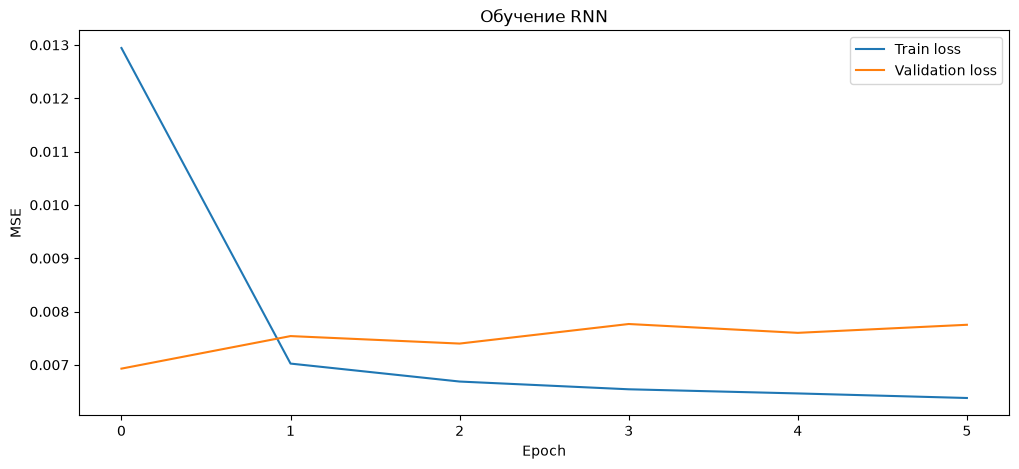

In [25]:
plt.figure(figsize=(12, 5))

plt.plot(
    history.history["loss"],
    label="Train loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE")

plt.title("Обучение RNN")

plt.legend()

plt.show()


In [26]:
pred_scaled = model.predict(
    X_test,
    batch_size=256
)


117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step


In [27]:
pred = scaler.inverse_transform(
    pred_scaled
).flatten()

actual = scaler.inverse_transform(
    y_test
).flatten()


In [28]:
pred = np.clip(
    pred,
    0,
    1
)


In [29]:
mae = mean_absolute_error(
    actual,
    pred
)

print(f"MAE: {mae:.6f}")


MAE: 0.046756


In [30]:
rmse = np.sqrt(
    mean_squared_error(
        actual,
        pred
    )
)

print(f"RMSE: {rmse:.6f}")


RMSE: 0.077491


In [31]:
rnn_results = pd.DataFrame({
    "actual": actual,
    "prediction": pred
})

rnn_results["error"] = (
    rnn_results["actual"]
    - rnn_results["prediction"]
)

rnn_results.head()


,actual,prediction,error
0,0.44,0.418623,0.021377
1,0.40,0.426235,-0.026235
2,0.40,0.374243,0.025757
3,0.39,0.380154,0.009846
4,0.22,0.362091,-0.142091


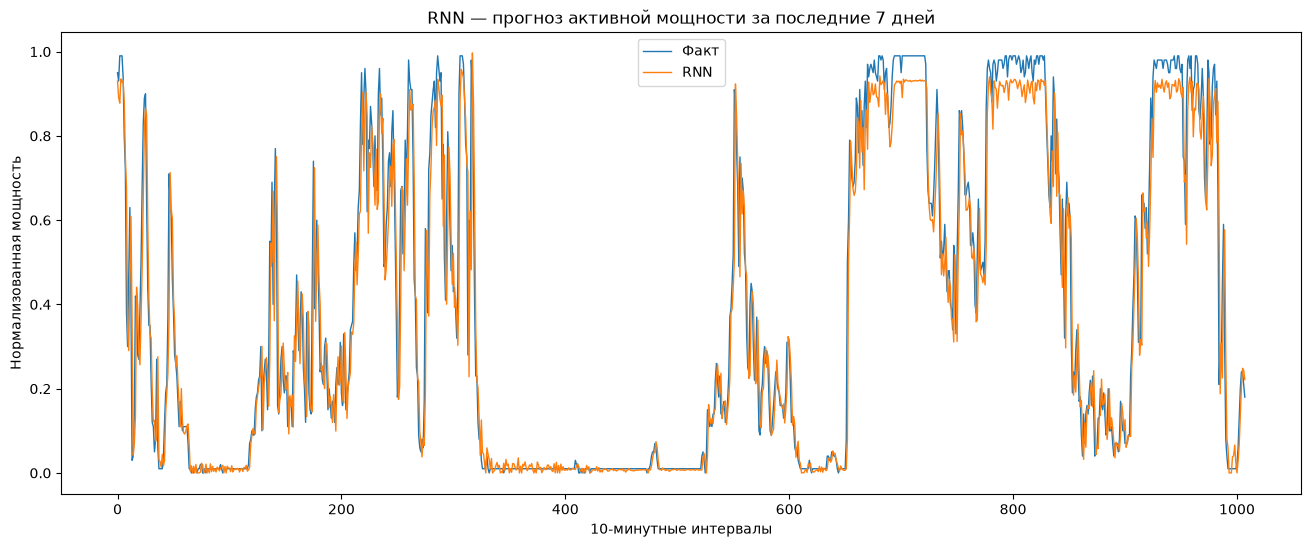

In [32]:
n = 144 * 7

plt.figure(figsize=(16, 6))

plt.plot(
    actual[-n:],
    label="Факт",
    linewidth=1
)

plt.plot(
    pred[-n:],
    label="RNN",
    linewidth=1
)

plt.title(
    "RNN — прогноз активной мощности за последние 7 дней"
)

plt.xlabel("10-минутные интервалы")
plt.ylabel("Нормализованная мощность")

plt.legend()

plt.show()


In [33]:
model.save(
    "model_artifacts/rnn_wind_power.keras"
)

In [ ]:
rnn_results.to_csv(
    "model_artifacts/rnn_predictions.csv",
    index=False
)


In [35]:
features = [
    "Средняя скорость ветра(m/s)",
    "Нормализованная активная мощность",
    "Средняя температура окружающей среды(°C)"
]

data = df[features].astype("float32").values

print(data.shape)


(149499, 3)


In [36]:
train_size = int(len(data) * 0.8)

train_data = data[:train_size]
test_data = data[train_size:]


In [37]:
scaler_features = MinMaxScaler()

train_scaled = scaler_features.fit_transform(
    train_data
)

test_scaled = scaler_features.transform(
    test_data
)


In [38]:
def create_multivariate_sequences(
    data,
    seq_len,
    target_idx=1
):
    
    X = []
    y = []
    
    for i in range(seq_len, len(data)):
        
        X.append(
            data[i-seq_len:i]
        )
        
        y.append(
            data[i, target_idx]
        )
    
    return np.array(X), np.array(y)


In [39]:
X_train, y_train = create_multivariate_sequences(
    train_scaled,
    SEQ_LEN,
    target_idx=1
)

print(X_train.shape)
print(y_train.shape)


(119455, 144, 3)
(119455,)


In [40]:
test_input = np.concatenate([
    train_scaled[-SEQ_LEN:],
    test_scaled
])

X_test, y_test = create_multivariate_sequences(
    test_input,
    SEQ_LEN,
    target_idx=1
)

print(X_test.shape)
print(y_test.shape)


(29900, 144, 3)
(29900,)


In [41]:
model_multi = Sequential([
    
    SimpleRNN(
        64,
        input_shape=(SEQ_LEN, 3),
        return_sequences=False
    ),
    
    Dropout(0.2),
    
    Dense(32, activation="relu"),
    
    Dense(1)
])


c:\python_projects\hack-292e04fe-neurohub\env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [42]:
model_multi.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)


In [43]:
history_multi = model_multi.fit(
    X_train,
    y_train,
    
    epochs=30,
    batch_size=256,
    
    validation_split=0.1,
    
    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )
    ],
    
    verbose=1
)


Epoch 1/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - loss: 0.0208 - mae: 0.0901 - val_loss: 0.0074 - val_mae: 0.0531
Epoch 2/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - loss: 0.0080 - mae: 0.0597 - val_loss: 0.0075 - val_mae: 0.0579
Epoch 3/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 0.0072 - mae: 0.0553 - val_loss: 0.0076 - val_mae: 0.0593
Epoch 4/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 0.0069 - mae: 0.0532 - val_loss: 0.0074 - val_mae: 0.0569
Epoch 5/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 0.0068 - mae: 0.0522 - val_loss: 0.0072 - val_mae: 0.0547
Epoch 6/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 0.0066 - mae: 0.0513 - val_loss: 0.0072 - val_mae: 0.0549
Epoch 7/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - loss: 0.0065 - mae: 0.0506 - val_loss: 0.0073 - val_mae: 0.0551
Epoch 8/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 0.0065 - mae: 0.0502 - val_loss: 0.0071 - val_mae: 0.0543
Epoch 9/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms

In [44]:
pred_scaled = model_multi.predict(
    X_test,
    batch_size=256
).flatten()


117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step


In [45]:
power_min = scaler_features.data_min_[1]
power_max = scaler_features.data_max_[1]

pred_multi = (
    pred_scaled * (power_max - power_min)
    + power_min
)

actual_multi = (
    y_test * (power_max - power_min)
    + power_min
)

pred_multi = np.clip(
    pred_multi,
    0,
    1
)


In [46]:
mae_multi = mean_absolute_error(
    actual_multi,
    pred_multi
)

rmse_multi = np.sqrt(
    mean_squared_error(
        actual_multi,
        pred_multi
    )
)

print(f"MAE  = {mae_multi:.6f}")
print(f"RMSE = {rmse_multi:.6f}")


MAE  = 0.047258
RMSE = 0.077472


In [49]:
comparison = pd.DataFrame({
    "Model": [
        "RNN",
        "Multivariate RNN"
    ],
    "MAE": [
        mae,
        mae_multi
    ],
    "RMSE": [
        rmse,
        rmse_multi
    ]
})

comparison


,Model,MAE,RMSE
0,RNN,0.046756,0.077491
1,Multivariate RNN,0.047258,0.077472
